# Matrix-Vector Multiplication

## Purpose

Understand matrix-vector multiplication as a way of rebuilding a vector from transformed basis vectors.

In the earlier notebooks, we worked with vectors, dot products, cosine similarity, projections and components.

This notebook introduces the next idea:

> a matrix can transform a vector by moving the basis vectors, then rebuilding the vector from those moved basis vectors.

For now, we will use 2D vectors and 2×2 matrices because they are easy to calculate and plot.


## Helpers

These helpers keep the plotting code out of the main examples.

They are deliberately simple: the important teaching choices, such as axis limits and label positions, stay visible in the notebook cells.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_axis(ax, title, xlim=(-4, 4), ylim=(-4, 4)):
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_arrow(
    ax,
    start,
    vector,
    label=None,
    label_offset=(0.08, 0.08),
    linewidth=2,
    linestyle="-",
    alpha=1.0,
    head_width=0.08,
    head_length=0.12,
):
    start = np.array(start, dtype=float)
    vector = np.array(vector, dtype=float)
    end = start + vector

    ax.arrow(
        start[0],
        start[1],
        vector[0],
        vector[1],
        length_includes_head=True,
        head_width=head_width,
        head_length=head_length,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=alpha,
    )

    if label is not None:
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=11,
        )


def print_vector(name, vector):
    print(f"{name} = [{vector[0]: .2f}, {vector[1]: .2f}]")


## Coordinates as basis-vector instructions

The standard basis vectors are:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

A vector's coordinates tell us how to build it from those basis vectors.

For example:

$$
\mathbf{v} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
=
2\mathbf{e}_1 + 1\mathbf{e}_2
$$

So the vector is not just an arrow. It is also a set of instructions:

> go two steps in the $\mathbf{e}_1$ direction, then one step in the $\mathbf{e}_2$ direction.


In [2]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])

v = np.array([2, 1])

built_v = 2 * e1 + 1 * e2

print_vector("e1", e1)
print_vector("e2", e2)
print_vector("v", v)
print_vector("2e1 + 1e2", built_v)


e1 = [ 1.00,  0.00]
e2 = [ 0.00,  1.00]
v = [ 2.00,  1.00]
2e1 + 1e2 = [ 2.00,  1.00]


The calculation confirms that $\mathbf{v}$ can be built from the standard basis vectors.

Now we can ask what happens when a matrix transforms those basis vectors.


## A matrix moves the basis vectors

Here is a simple 2×2 matrix:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
$$

This matrix doubles horizontal movement and leaves vertical movement unchanged.

Instead of starting by applying $A$ to $\mathbf{v}$, we will first apply it to the basis vectors.


In [3]:
A = np.array([
    [2, 0],
    [0, 1],
])

Ae1 = A @ e1
Ae2 = A @ e2

print("A:")
print(A)
print()
print_vector("Ae1", Ae1)
print_vector("Ae2", Ae2)


A:
[[2 0]
 [0 1]]

Ae1 = [ 2.00,  0.00]
Ae2 = [ 0.00,  1.00]


The transformed basis vectors are:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
2 \\
0
\end{bmatrix}
\qquad
A\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

These are the columns of $A$.

So we can read the matrix like this:

- the first column is where $\mathbf{e}_1$ lands
- the second column is where $\mathbf{e}_2$ lands


## Matrix-vector multiplication rebuilds the vector

Before the transformation, our vector was:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

After the transformation, the coefficients stay the same, but the basis vectors have moved:

$$
A\mathbf{v}
=
2(A\mathbf{e}_1) + 1(A\mathbf{e}_2)
$$

Now calculate that directly.


In [4]:
Av = A @ v

rebuilt_Av = 2 * Ae1 + 1 * Ae2

print_vector("Av", Av)
print_vector("2Ae1 + 1Ae2", rebuilt_Av)


Av = [ 4.00,  1.00]
2Ae1 + 1Ae2 = [ 4.00,  1.00]


The two results match.

That is the central idea of this notebook:

> matrix-vector multiplication rebuilds the vector using the transformed basis vectors.


## The row-arithmetic view

NumPy calculates the result using matrix-vector multiplication.

For this matrix and vector:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 1
\end{bmatrix}
\qquad
\mathbf{v} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

the arithmetic is:

$$
A\mathbf{v}
=
\begin{bmatrix}
2 \times 2 + 0 \times 1 \\
0 \times 2 + 1 \times 1
\end{bmatrix}
=
\begin{bmatrix}
4 \\
1
\end{bmatrix}
$$

This is the same result as rebuilding the vector from the transformed basis vectors.


In [5]:
manual_Av = np.array([
    2 * v[0] + 0 * v[1],
    0 * v[0] + 1 * v[1],
])

numpy_Av = A @ v

print_vector("manual Av", manual_Av)
print_vector("NumPy Av", numpy_Av)


manual Av = [ 4.00,  1.00]
NumPy Av = [ 4.00,  1.00]


## Before and after

The same idea is easier to see geometrically.

On the left, $\mathbf{v}$ is built from the standard basis vectors.

On the right, $A\mathbf{v}$ is built from the transformed basis vectors.

The coefficients are still $2$ and $1$.


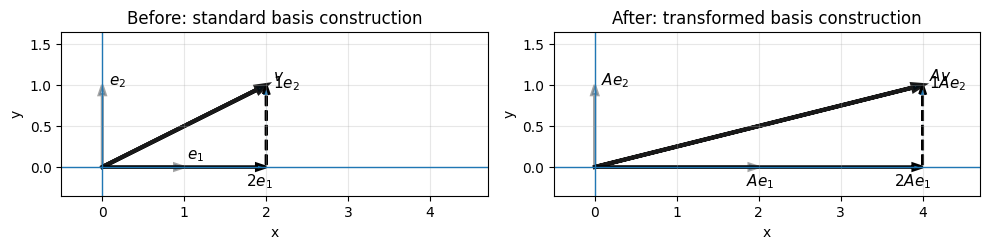

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

shared_xlim = (-0.5, 4.7)
shared_ylim = (-0.35, 1.65)

setup_axis(
    axes[0],
    "Before: standard basis construction",
    xlim=shared_xlim,
    ylim=shared_ylim,
)

draw_arrow(axes[0], (0, 0), e1, "$e_1$", label_offset=(0.03, 0.10), alpha=0.35)
draw_arrow(axes[0], (0, 0), e2, "$e_2$", label_offset=(0.08, 0.00), alpha=0.35)
draw_arrow(axes[0], (0, 0), 2 * e1, "$2e_1$", label_offset=(-0.25, -0.23), linewidth=2)
draw_arrow(axes[0], 2 * e1, 1 * e2, "$1e_2$", label_offset=(0.08, -0.03), linewidth=2, linestyle="--")
draw_arrow(axes[0], (0, 0), v, "$v$", label_offset=(0.08, 0.06), linewidth=3, alpha=0.9)

setup_axis(
    axes[1],
    "After: transformed basis construction",
    xlim=shared_xlim,
    ylim=shared_ylim,
)

draw_arrow(axes[1], (0, 0), Ae1, "$Ae_1$", label_offset=(-0.15, -0.23), alpha=0.35)
draw_arrow(axes[1], (0, 0), Ae2, "$Ae_2$", label_offset=(0.08, 0.00), alpha=0.35)
draw_arrow(axes[1], (0, 0), 2 * Ae1, "$2Ae_1$", label_offset=(-0.35, -0.23), linewidth=2)
draw_arrow(axes[1], 2 * Ae1, 1 * Ae2, "$1Ae_2$", label_offset=(0.08, -0.03), linewidth=2, linestyle="--")
draw_arrow(axes[1], (0, 0), Av, "$Av$", label_offset=(0.08, 0.06), linewidth=3, alpha=0.9)

plt.tight_layout()
plt.show()


The transformed vector is longer in the horizontal direction because $A$ moved $\mathbf{e}_1$ from $[1, 0]$ to $[2, 0]$.

The vector still uses the same coefficients:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

$$
A\mathbf{v} = 2(A\mathbf{e}_1) + 1(A\mathbf{e}_2)
$$


## Trying a second vector

The matrix is not just a rule for one vector.

Let's try a second vector with a negative coefficient:

$$
\mathbf{w} =
\begin{bmatrix}
-1 \\
2
\end{bmatrix}
=
-1\mathbf{e}_1 + 2\mathbf{e}_2
$$

The negative coefficient means we move in the opposite direction to $\mathbf{e}_1$.


In [7]:
w = np.array([-1, 2])

Aw = A @ w
rebuilt_Aw = -1 * Ae1 + 2 * Ae2

print_vector("w", w)
print_vector("Aw", Aw)
print_vector("-1Ae1 + 2Ae2", rebuilt_Aw)


w = [-1.00,  2.00]
Aw = [-2.00,  2.00]
-1Ae1 + 2Ae2 = [-2.00,  2.00]


The same pattern still works:

$$
A\mathbf{w}
=
-1(A\mathbf{e}_1) + 2(A\mathbf{e}_2)
$$

The coefficients are $-1$ and $2$ before the transformation, and they are still $-1$ and $2$ after the transformation.


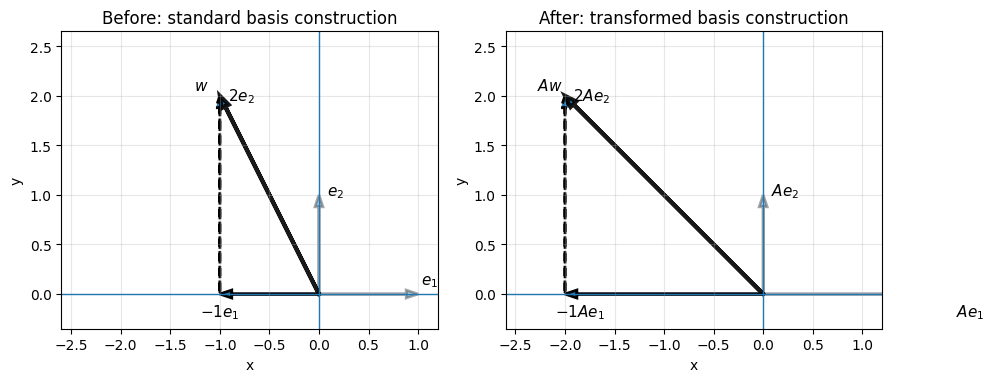

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

shared_xlim = (-2.6, 1.2)
shared_ylim = (-0.35, 2.65)

setup_axis(
    axes[0],
    "Before: standard basis construction",
    xlim=shared_xlim,
    ylim=shared_ylim,
)

draw_arrow(axes[0], (0, 0), e1, "$e_1$", label_offset=(0.03, 0.10), alpha=0.35)
draw_arrow(axes[0], (0, 0), e2, "$e_2$", label_offset=(0.08, 0.00), alpha=0.35)
draw_arrow(axes[0], (0, 0), -1 * e1, "$-1e_1$", label_offset=(-0.20, -0.23), linewidth=2)
draw_arrow(axes[0], -1 * e1, 2 * e2, "$2e_2$", label_offset=(0.08, -0.05), linewidth=2, linestyle="--")
draw_arrow(axes[0], (0, 0), w, "$w$", label_offset=(-0.26, 0.06), linewidth=3, alpha=0.9)

setup_axis(
    axes[1],
    "After: transformed basis construction",
    xlim=shared_xlim,
    ylim=shared_ylim,
)

draw_arrow(axes[1], (0, 0), Ae1, "$Ae_1$", label_offset=(-0.05, -0.23), alpha=0.35)
draw_arrow(axes[1], (0, 0), Ae2, "$Ae_2$", label_offset=(0.08, 0.00), alpha=0.35)
draw_arrow(axes[1], (0, 0), -1 * Ae1, "$-1Ae_1$", label_offset=(-0.10, -0.23), linewidth=2)
draw_arrow(axes[1], -1 * Ae1, 2 * Ae2, "$2Ae_2$", label_offset=(0.08, -0.05), linewidth=2, linestyle="--")
draw_arrow(axes[1], (0, 0), Aw, "$Aw$", label_offset=(-0.28, 0.06), linewidth=3, alpha=0.9)

plt.tight_layout()
plt.show()


Again, the horizontal part changes because $A$ moved $\mathbf{e}_1$.

The vertical part is unchanged because $A$ left $\mathbf{e}_2$ where it was.


## Summary

The standard basis vectors are:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

A vector with coordinates $x$ and $y$ can be read as:

$$
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
x\mathbf{e}_1 + y\mathbf{e}_2
$$

For a matrix $A$:

- the first column is where $\mathbf{e}_1$ lands
- the second column is where $\mathbf{e}_2$ lands
- matrix-vector multiplication rebuilds the vector using the transformed basis vectors
- the coefficients stay the same; the basis vectors change

The central idea is:

$$
A
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
x(A\mathbf{e}_1) + y(A\mathbf{e}_2)
$$

So a matrix is not just a grid of numbers. In this notebook, we can read it as a transformation that moves the basis vectors, then rebuilds every other vector from those transformed basis vectors.

## Next step

Next, we can use this idea to understand specific transformations such as scaling, reflection and shear.
